In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)

In [3]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [4]:
df['Sub_metering_1'] = pd.to_numeric(df['Sub_metering_1'], errors='coerce')
df['Sub_metering_2'] = pd.to_numeric(df['Sub_metering_2'], errors='coerce')
df['Sub_metering_3'] = pd.to_numeric(df['Sub_metering_3'], errors='coerce')

In [5]:
df['Datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])

C:\Users\yasmi\AppData\Local\Temp\ipykernel_13924\570100312.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])


In [6]:
df[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].describe()

,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.121923e+00,1.298520e+00,6.458447e+00
std,6.153031e+00,5.822026e+00,8.437154e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,1.000000e+00
75%,0.000000e+00,1.000000e+00,1.700000e+01
max,8.800000e+01,8.000000e+01,3.100000e+01


C:\Users\yasmi\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


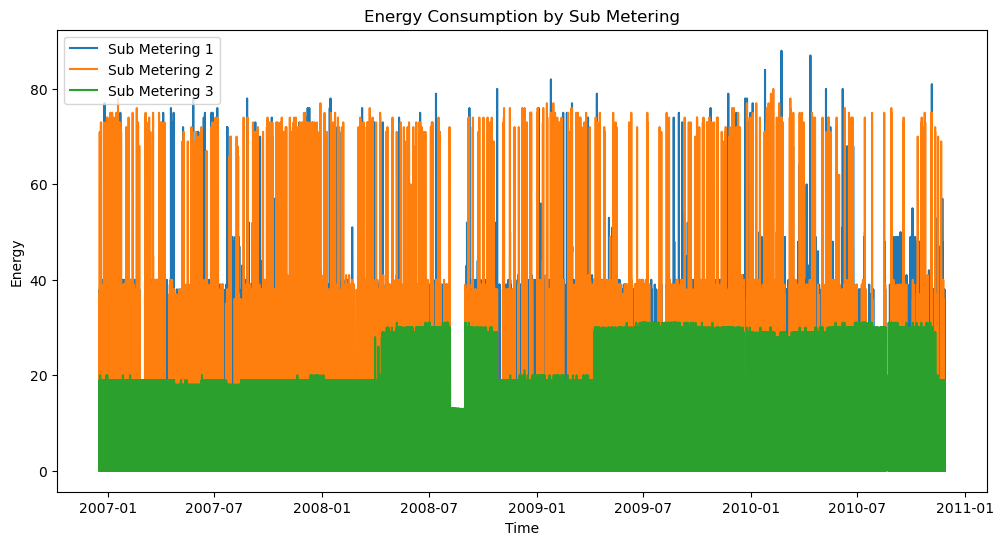

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df['Datetime'], df['Sub_metering_1'], label="Sub Metering 1")
plt.plot(df['Datetime'], df['Sub_metering_2'], label="Sub Metering 2")
plt.plot(df['Datetime'], df['Sub_metering_3'], label="Sub Metering 3")

plt.legend()
plt.title("Energy Consumption by Sub Metering")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.show()

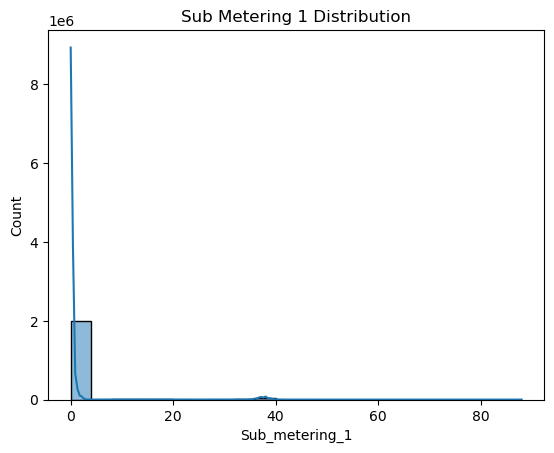

In [8]:
sns.histplot(df['Sub_metering_1'], kde=True)
plt.title("Sub Metering 1 Distribution")
plt.show()

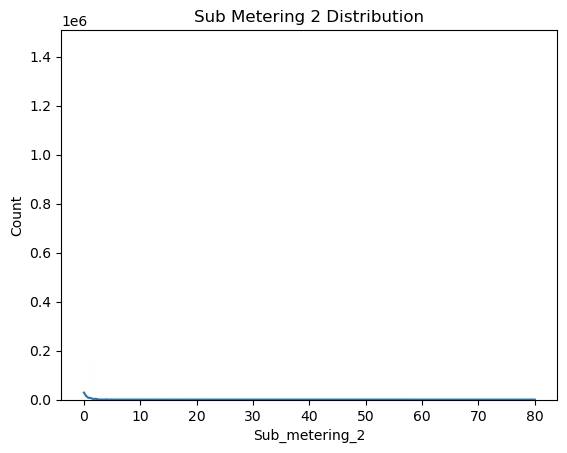

In [9]:
sns.histplot(df['Sub_metering_2'], kde=True)
plt.title("Sub Metering 2 Distribution")
plt.show()

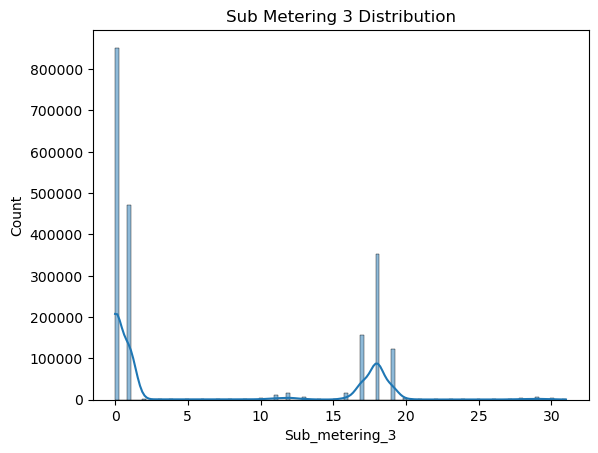

In [10]:
sns.histplot(df['Sub_metering_3'], kde=True)
plt.title("Sub Metering 3 Distribution")
plt.show()

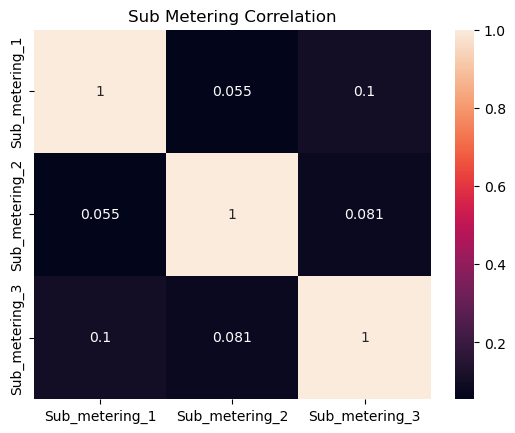

In [11]:
sns.heatmap(df[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].corr(), annot=True)
plt.title("Sub Metering Correlation")
plt.show()

In [13]:
anomaly_times = pd.read_csv("anomaly_times.csv")
anomaly_times.columns = ['Datetime']
anomaly_times['Datetime'] = pd.to_datetime(anomaly_times['Datetime'])

In [14]:
anomaly_rows = df[df['Datetime'].isin(anomaly_times['Datetime'])]

anomaly_rows[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].head()

,Sub_metering_1,Sub_metering_2,Sub_metering_3
8856,2.0,0.0,17.0
9516,0.0,0.0,17.0
9936,0.0,0.0,18.0
9996,0.0,0.0,18.0
10056,37.0,0.0,17.0


In [15]:
sub_means = anomaly_rows[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].mean()

total = sub_means.sum()

sub_percent = (sub_means / total) * 100

print("Sub-meter anomaly contribution (%)")
print(sub_percent)

Sub-meter anomaly contribution (%)
Sub_metering_1    26.897673
Sub_metering_2    31.876842
Sub_metering_3    41.225485
dtype: float64


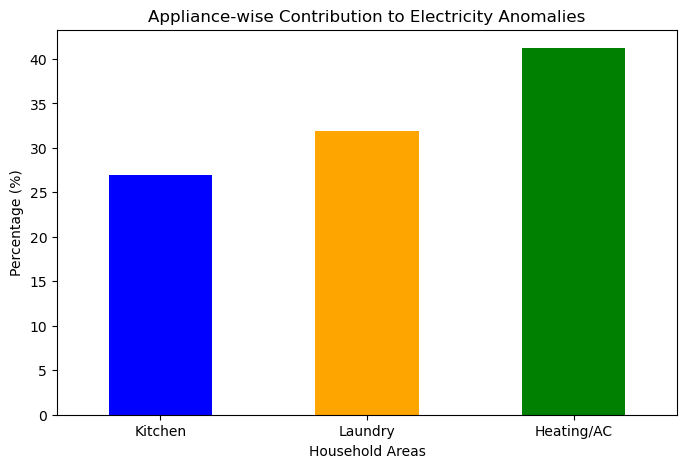

In [18]:
sub_percent.index = ['Kitchen','Laundry','Heating/AC']

plt.figure(figsize=(8,5))

sub_percent.plot(
    kind='bar',
    color=['blue','orange','green']
)

plt.title("Appliance-wise Contribution to Electricity Anomalies")
plt.ylabel("Percentage (%)")
plt.xlabel("Household Areas")

plt.xticks(rotation=0)

plt.show()

In [19]:
area_usage = df[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].sum()

area_usage.index = ['Kitchen','Laundry','Heating/AC']

print(area_usage)

Kitchen        2299135.0
Laundry        2661031.0
Heating/AC    13235167.0
dtype: float64


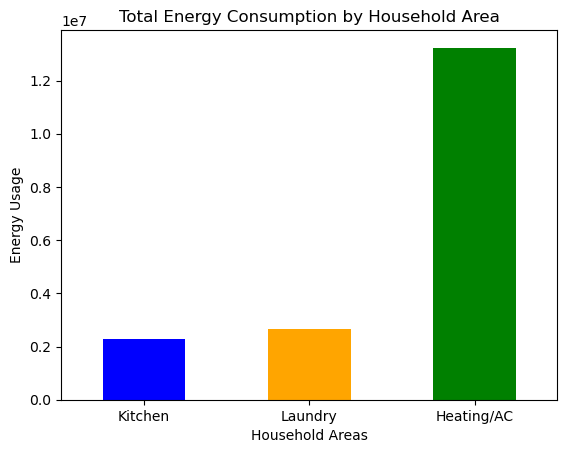

In [20]:
area_usage.plot(kind='bar', color=['blue','orange','green'])

plt.title("Total Energy Consumption by Household Area")
plt.ylabel("Energy Usage")
plt.xlabel("Household Areas")

plt.xticks(rotation=0)
plt.show()

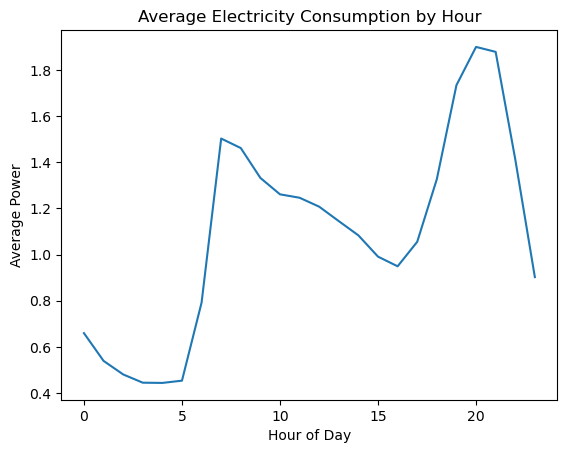

In [22]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

hourly_usage = df.groupby(df['Datetime'].dt.hour)['Global_active_power'].mean()

hourly_usage.plot(kind='line')

plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power")

plt.show()

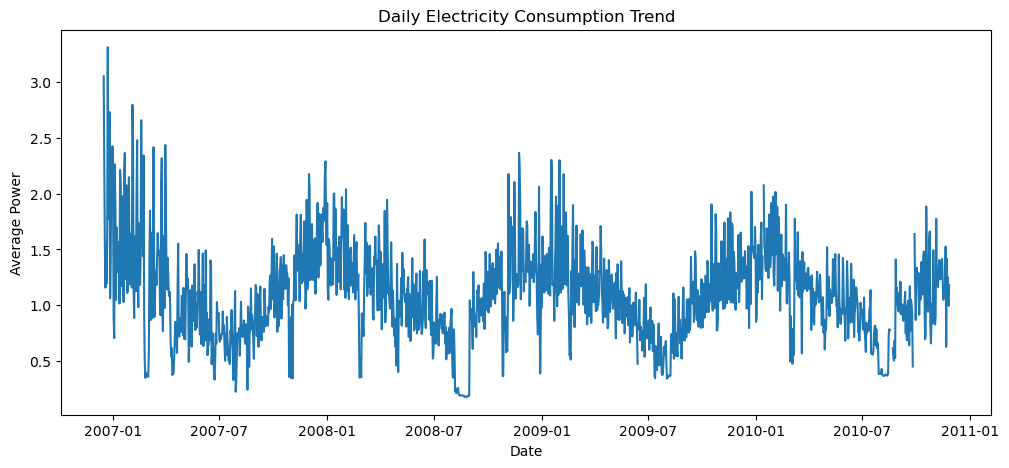

In [23]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

daily_usage = df.groupby(df['Datetime'].dt.date)['Global_active_power'].mean()

daily_usage.plot(figsize=(12,5))

plt.title("Daily Electricity Consumption Trend")
plt.xlabel("Date")
plt.ylabel("Average Power")
plt.show()

In [24]:
top_usage = df[['Datetime','Global_active_power']].sort_values(
    by='Global_active_power',
    ascending=False
).head(10)

print(top_usage)

                   Datetime  Global_active_power
1150545 2009-02-22 17:09:00               11.122
112450  2007-03-04 19:34:00               10.670
112449  2007-03-04 19:33:00               10.650
1150544 2009-02-22 17:08:00               10.536
1029775 2008-11-30 20:19:00               10.348
968160  2008-10-19 01:24:00               10.290
586200  2008-01-27 19:24:00               10.162
112448  2007-03-04 19:32:00               10.154
1029773 2008-11-30 20:17:00               10.074
968161  2008-10-19 01:25:00               10.064


In [27]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

In [28]:
df = df.sort_values('Datetime')

power_hourly = df.set_index('Datetime')['Global_active_power'].resample('h').mean()

In [29]:
normal_usage = power_hourly.mean()
max_usage = power_hourly.max()

efficiency_score = (normal_usage / max_usage) * 100

print("Energy Efficiency Score:", round(efficiency_score,2), "%")

Energy Efficiency Score: 16.64 %


In [33]:
threshold = power_hourly.mean() + power_hourly.std()

print("Threshold: ",threshold)
df['wastage_alert'] = df['Global_active_power'].apply(
    lambda x: "High Usage" if x > threshold else "Normal"
)
print("Maximum Power: ",power_hourly.max())

Threshold:  1.9893466376960678
Maximum Power:  6.560533333333334


In [34]:
df['wastage_alert'] = df['Global_active_power'].apply(
    lambda x: "High Usage" if x > threshold else "Normal"
)

print(df['wastage_alert'].value_counts())

wastage_alert
Normal        1766076
High Usage     309183
Name: count, dtype: int64


In [35]:
high_usage = df[df['Global_active_power'] > threshold]

print(high_usage[['Datetime','Global_active_power']].head())

             Datetime  Global_active_power
0 2006-12-16 17:24:00                4.216
1 2006-12-16 17:25:00                5.360
2 2006-12-16 17:26:00                5.374
3 2006-12-16 17:27:00                5.388
4 2006-12-16 17:28:00                3.666


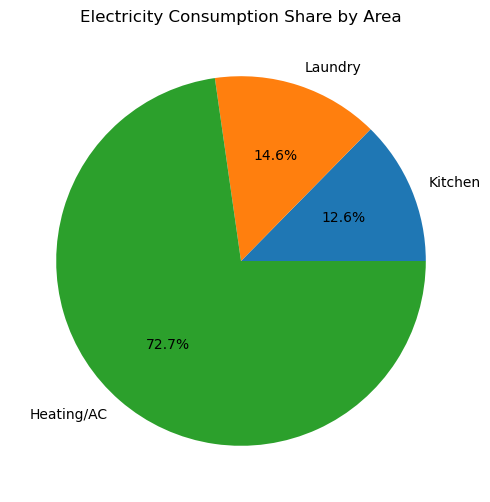

In [36]:
area_usage.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Electricity Consumption Share by Area")
plt.ylabel("")
plt.show()

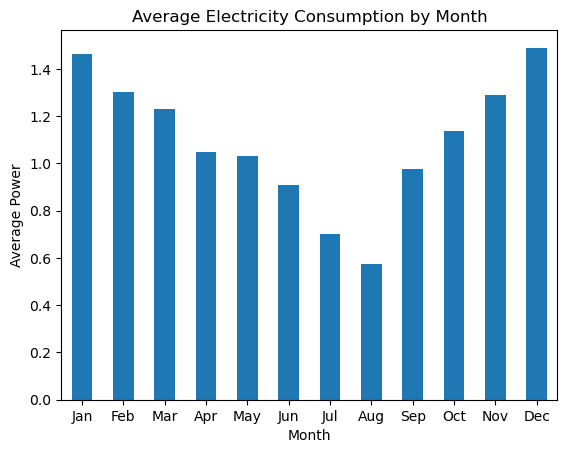

In [38]:
monthly_usage.index = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_usage.plot(kind='bar')

plt.title("Average Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Power")

plt.xticks(rotation=0)

plt.show()